In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory
from collections import Counter
import numpy as np
import shutil
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tensorflow.keras.preprocessing.image import load_img,img_to_array,save_img

In [3]:
BATCH_SIZE=32

In [4]:
dataset_path = "fingerprint_dataset"

dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="int",
    image_size=(64, 64),
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 6000 files belonging to 8 classes.


In [5]:
class_names=dataset.class_names
class_counts=Counter()
for _,labels in dataset.unbatch():
    class_counts[int(labels.numpy())]+=1
print("Class Distribution:")

for i,count in class_counts.items():
    print(f"{class_names[i]}:{count}")

Class Distribution:
AB+:708
A-:1009
O+:852
B-:741
A+:565
O-:712
AB-:761
B+:652


In [6]:
import matplotlib.pyplot as plt
def plot_class_distribution(class_names,class_counts):
    classes = [class_names[i] for i  in class_counts.keys()]
    counts=[class_counts[i] for i in class_counts.keys()]

    plt.figure(figsize=(10,6))

In [7]:
import matplotlib.pyplot as plt

def plot_class_distribution(class_names, class_counts):
    # Assuming class_counts is a dict like {'cat': 500, 'dog': 800, ...}
    classes = [class_names[i] for i in class_counts.keys()]  # if class_names is a list
    counts = [class_counts[i] for i in class_counts.keys()]

    plt.figure(figsize=(10, 6))
    plt.bar(classes, counts, color='skyblue')
    plt.xlabel('Class Names')
    plt.ylabel('Number of Samples')
    plt.title('Class Distribution')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


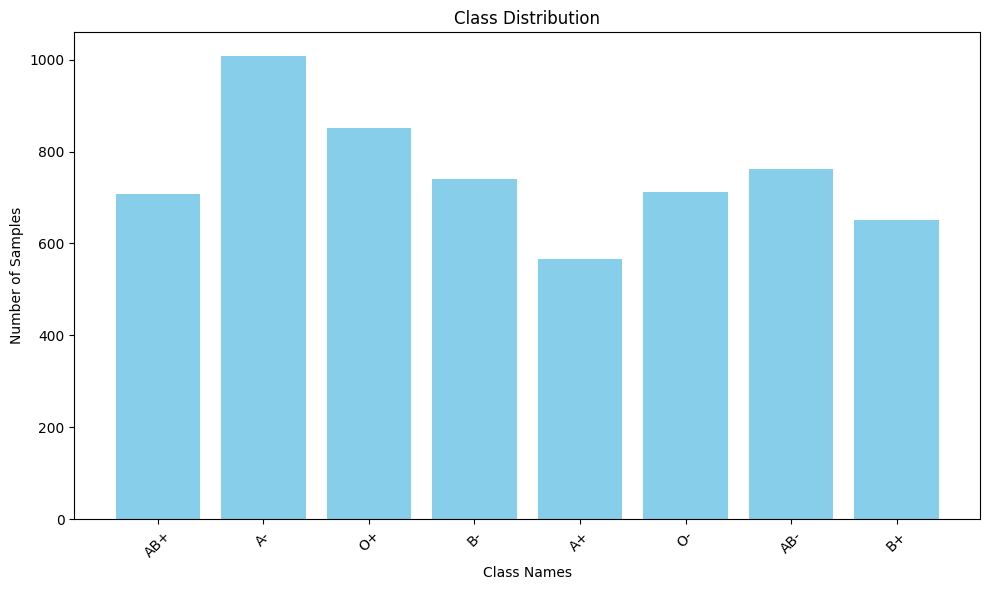

In [8]:
plot_class_distribution(class_names,class_counts)

In [9]:
max_count=max(class_counts.values())
print(max_count)

1009


In [10]:
def oversample_class(class_id,count,max_count):
    unbatched_dataset=dataset.unbatch()
    class_dataset=unbatched_dataset.filter(lambda img,lbl:tf.equal(lbl,class_id))
    repeat_factor=max_count// count+(max_count % count >0)
    return class_dataset.repeat(repeat_factor).take(max_count)

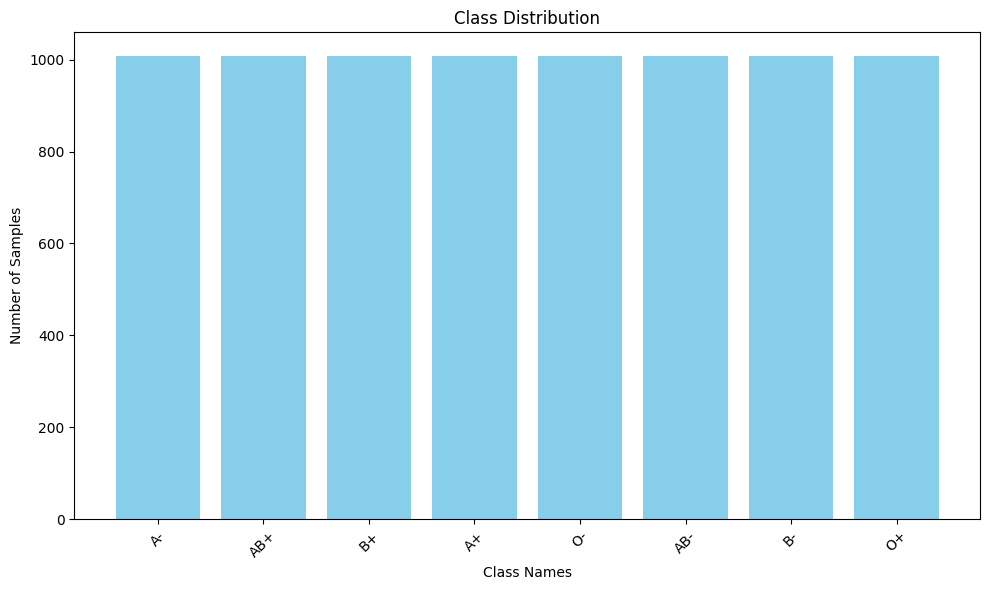

In [11]:
balanced_datasets=[]
for class_id,count in class_counts.items():
    balanced_datasets.append(oversample_class(class_id,count,max_count))
balanced_dataset=tf.data.Dataset.sample_from_datasets(balanced_datasets)

balanced_class_counts=Counter([int(lbl.numpy()) for _,lbl in balanced_dataset])
plot_class_distribution(class_names,balanced_class_counts)
balanced_dataset=balanced_dataset.batch(BATCH_SIZE,drop_remainder=True)

In [12]:
for sample in balanced_dataset.take(10):
    print(sample[0].shape)

(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)


In [13]:
balanced_dataset_unbatched=balanced_dataset.unbatch()
dataset_size=sum(1 for _ in balanced_dataset_unbatched)
print(f"Total dataset size: {dataset_size}") 

Total dataset size: 8064


In [14]:
balanced_dataset_unbatched=balanced_dataset.unbatch()
train_ratio=0.7
val_ratio=0.2
test_ratio=0.1

train_size=int(train_ratio * dataset_size)
val_size=int(val_ratio * dataset_size)

train_dataset=balanced_dataset_unbatched.take(train_size)
val_test_dataset=balanced_dataset_unbatched.skip(train_size)
val_dataset=val_test_dataset.take(val_size)
test_dataset=val_test_dataset.skip(val_size)

train_dataset=train_dataset.batch(BATCH_SIZE,drop_remainder=True)
val_dataset=val_dataset.batch(BATCH_SIZE,drop_remainder=True)
test_dataset=test_dataset.batch(BATCH_SIZE,drop_remainder=True)


train_batch_count=sum(1 for _ in train_dataset)
val_batch_count=sum(1 for _ in val_dataset)
test_batch_count=sum(1 for _ in test_dataset)

print(f"TRAINING dataset size:{train_batch_count * BATCH_SIZE}")
print(f"VALIDATION dataset size:{val_batch_count * BATCH_SIZE}")
print(f"TESTING dataset size:{test_batch_count * BATCH_SIZE}")

TRAINING dataset size:5632
VALIDATION dataset size:1600
TESTING dataset size:800


In [15]:
def create_high_accuracy_model():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.4),

        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.4),

        tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.4),

        tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1024, activation='relu'),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(len(class_names), activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

high_accuracy_model = create_high_accuracy_model()


In [16]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # fixed underscore
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
    restore_best_weights=True
)


In [17]:

history_high_acc = high_accuracy_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50, 
    callbacks=[reduce_lr, early_stop]
)


Epoch 1/50
176/176 [==============================] - 32s 132ms/step - loss: 8.9274 - accuracy: 0.1319 - val_loss: 2.0789 - val_accuracy: 0.1231 - lr: 0.0010
Epoch 2/50
176/176 [==============================] - 24s 136ms/step - loss: 1.9940 - accuracy: 0.2061 - val_loss: 1.9967 - val_accuracy: 0.2731 - lr: 0.0010
Epoch 3/50
176/176 [==============================] - 25s 138ms/step - loss: 1.6705 - accuracy: 0.3549 - val_loss: 1.5860 - val_accuracy: 0.5106 - lr: 0.0010
Epoch 4/50
176/176 [==============================] - 25s 139ms/step - loss: 1.2380 - accuracy: 0.5389 - val_loss: 1.3309 - val_accuracy: 0.6525 - lr: 0.0010
Epoch 5/50
176/176 [==============================] - 25s 141ms/step - loss: 1.0296 - accuracy: 0.6252 - val_loss: 1.5697 - val_accuracy: 0.5119 - lr: 0.0010
Epoch 6/50
176/176 [==============================] - 26s 144ms/step - loss: 0.9232 - accuracy: 0.6655 - val_loss: 1.1457 - val_accuracy: 0.6825 - lr: 0.0010
Epoch 7/50
176/176 [==============================] 

In [18]:
high_acc_eval = high_accuracy_model.evaluate(val_dataset)
print(f"High Accuracy Model - Loss: {high_acc_eval[0]}, Accuracy: {high_acc_eval[1]}")


50/50 [==============================] - 14s 79ms/step - loss: 0.3570 - accuracy: 0.8988
High Accuracy Model - Loss: 0.35703808069229126, Accuracy: 0.8987500071525574


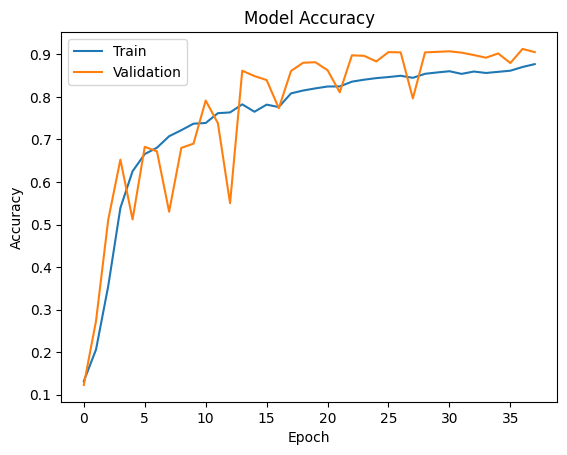

In [19]:
import matplotlib.pyplot as plt 

def plot_accuracy(history):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')  # Corrected here
    plt.show()

plot_accuracy(history_high_acc)


1/1 [==============================] - 0s 17ms/step
Classification Report:
              precision    recall  f1-score   support

          A+       0.97      0.95      0.96       115
          A-       0.96      0.76      0.85       131
         AB+       0.87      0.98      0.92        98
         AB-       0.86      0.97      0.91        63
          B+       0.81      0.94      0.87        71
          B-       0.93      0.91      0.92       151
          O+       0.80      0.84      0.82        77
          O-       0.95      0.91      0.93        94

    accuracy                           0.90       800
   macro avg       0.89      0.91      0.90       800
weighted avg       0.91      0.90      0.90       800



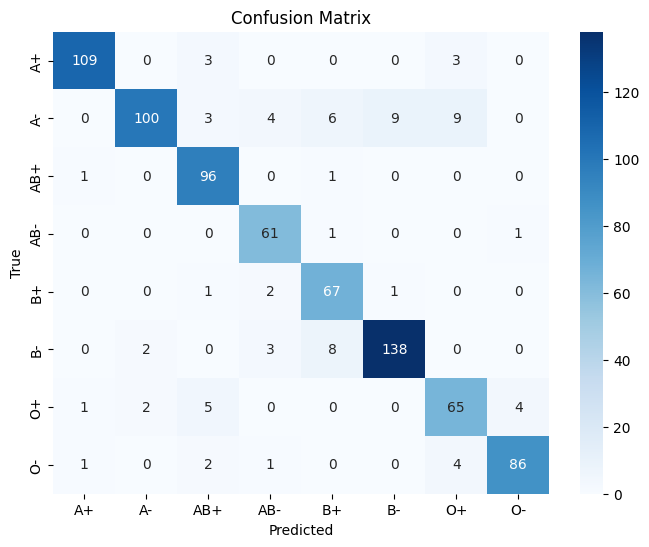

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = high_accuracy_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:")
print(report)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [30]:
high_accuracy_model.save('model.h5')
print("Model saved as HDF5 format")

Model saved as HDF5 format


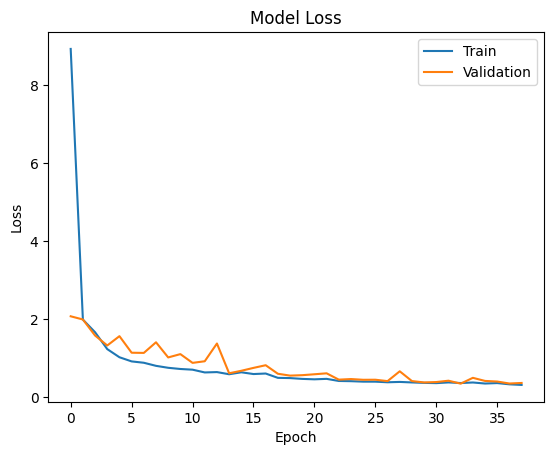

In [22]:
import matplotlib.pyplot as plt

def plot_loss(history):
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper right')
    plt.show()

plot_loss(history_high_acc)


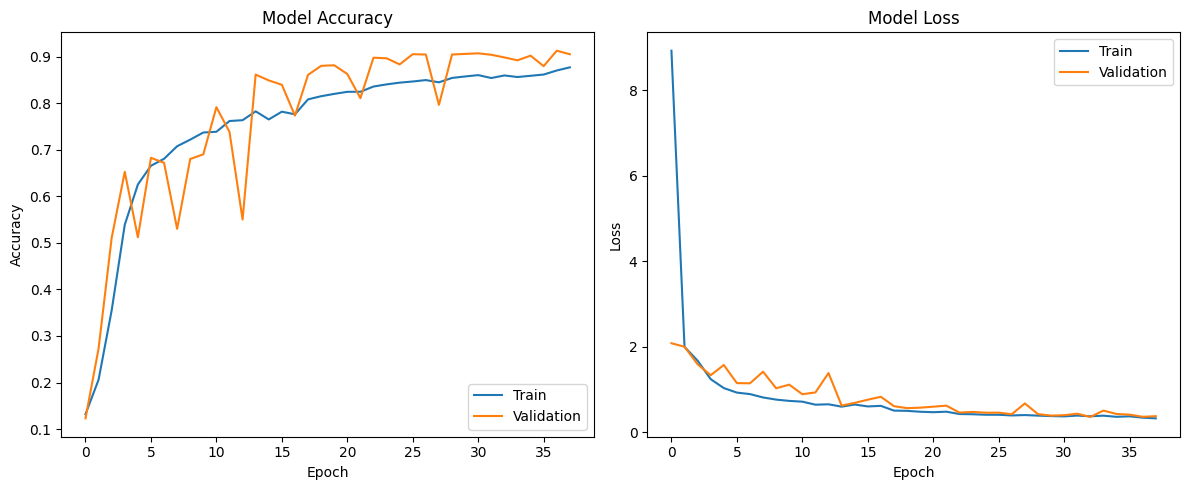

In [23]:
def plot_accuracy_and_loss(history):
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy
    axs[0].plot(history.history['accuracy'])
    axs[0].plot(history.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Accuracy')
    axs[0].legend(['Train', 'Validation'], loc='lower right')

    # Loss
    axs[1].plot(history.history['loss'])
    axs[1].plot(history.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].legend(['Train', 'Validation'], loc='upper right')

    plt.tight_layout()
    plt.show()

plot_accuracy_and_loss(history_high_acc)


1/1 [==============================] - 0s 16ms/step
Classification Report:
              precision    recall  f1-score   support

          A+       0.97      0.95      0.96       122
          A-       0.90      0.71      0.79        84
         AB+       0.78      0.99      0.87        74
         AB-       0.91      0.92      0.91       109
          B+       0.84      0.90      0.87        60
          B-       0.93      0.91      0.92       126
          O+       0.85      0.87      0.86        99
          O-       0.93      0.90      0.92       126

    accuracy                           0.90       800
   macro avg       0.89      0.89      0.89       800
weighted avg       0.90      0.90      0.90       800



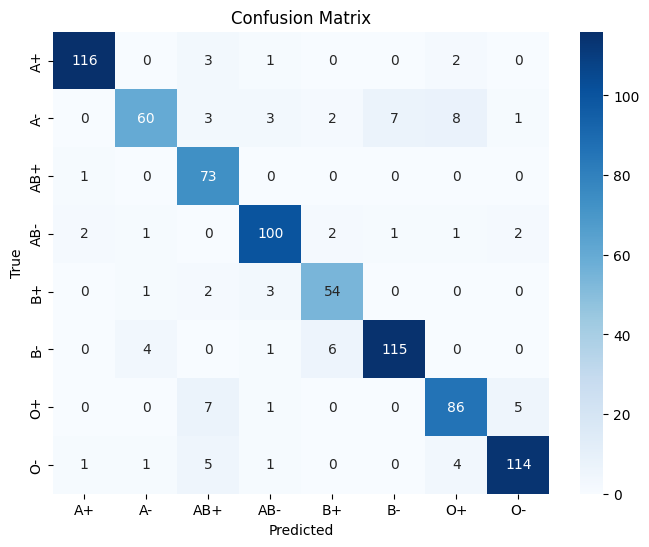

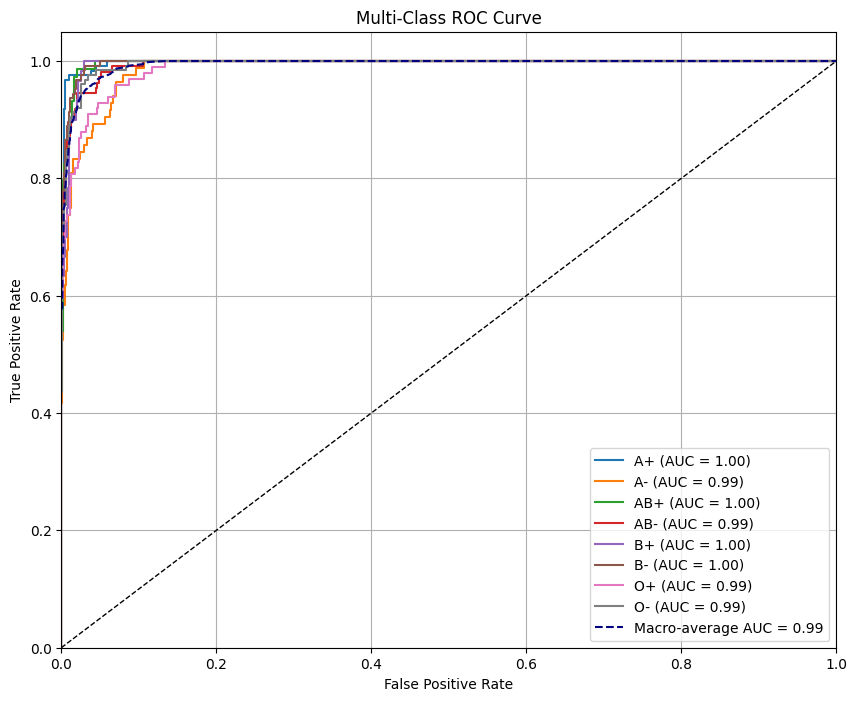

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true = []
y_score = []

# Collect true labels and predicted probabilities
for images, labels in test_dataset:
    predictions = high_accuracy_model.predict(images)
    y_score.extend(predictions)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_score = np.array(y_score)

# Get predicted class labels
y_pred = np.argmax(y_score, axis=1)

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:")
print(report)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# One-hot encode the true labels for ROC computation
y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))

# ROC Curve for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(class_names))]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(class_names)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= len(class_names)
macro_auc = auc(all_fpr, mean_tpr)

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(len(class_names)):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot(all_fpr, mean_tpr, color='navy', linestyle='--', label=f'Macro-average AUC = {macro_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

1/1 [==============================] - 0s 16ms/step


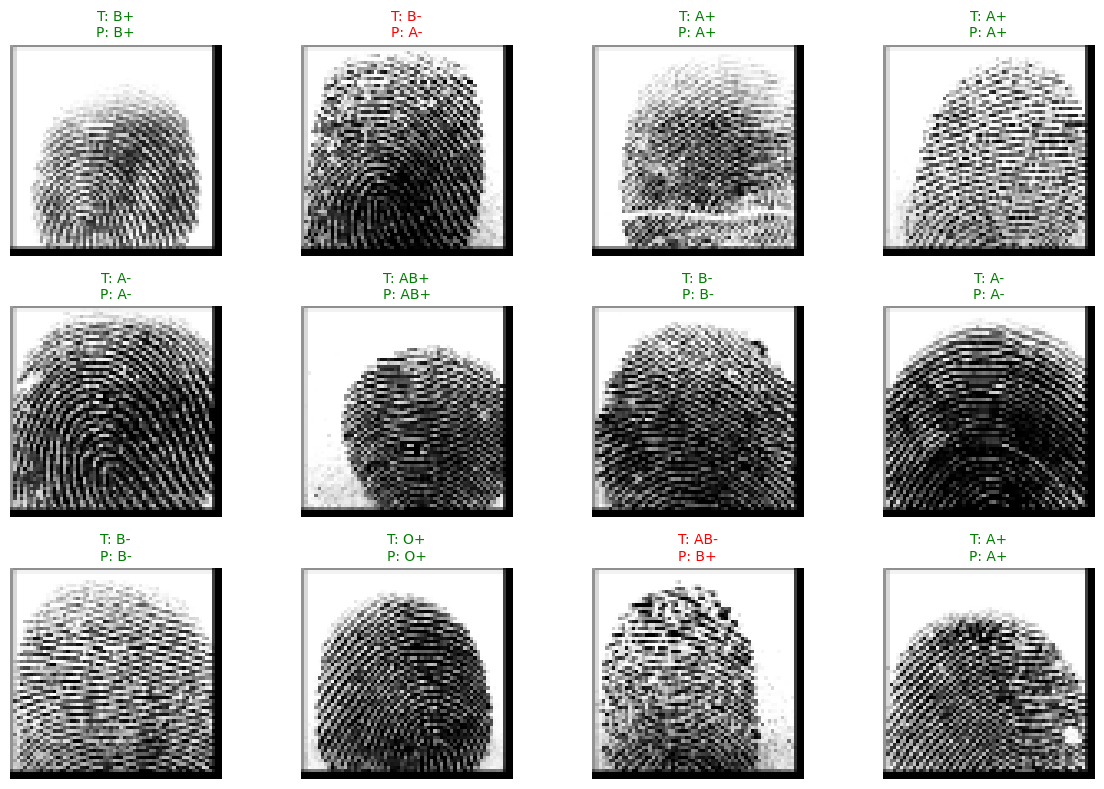

In [27]:
import os
import random
import shutil
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# 1. Display a grid of random Actual vs. Predicted images
def show_random_predictions(model, dataset, class_names, n=12):
    # collect all (img_tensor, label, filepath) triples
    samples = []
    for batch in dataset.unbatch().batch(1):
        img_tensor, label = batch
        # if you have access to the original filepath, store it; else skip filepath
        samples.append((img_tensor[0].numpy(), int(label[0].numpy())))
    # pick random indices
    picks = random.sample(samples, k=min(n, len(samples)))
    
    plt.figure(figsize=(12, 8))
    cols = 4
    rows = int(np.ceil(len(picks) / cols))
    for i, (img_arr, true_lbl) in enumerate(picks):
        # Model expects batch dimension
        pred_probs = model.predict(np.expand_dims(img_arr, axis=0))
        pred_lbl = np.argmax(pred_probs, axis=1)[0]
        
        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow(img_arr.astype('uint8'))
        plt.axis('off')
        title_color = 'green' if pred_lbl == true_lbl else 'red'
        ax.set_title(f"T: {class_names[true_lbl]}\nP: {class_names[pred_lbl]}",
                     color=title_color, fontsize=10)
    plt.tight_layout()
    plt.show()


# Usage:
show_random_predictions(high_accuracy_model, test_dataset, class_names, n=12)

In [29]:
class_names

['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']

In [36]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model('model.h5')

# Class names in the same order as used during training
class_names = ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']  # Replace with your actual class names

def predict_image(image_path):
    # Load image and resize to (64, 64)
    img = load_img(image_path, target_size=(64, 64))
    
    # Convert to array
    img_array = img_to_array(img)  # shape: (64, 64, 3)
    
    # Keep image in [0, 255] range (same as training); no normalization
    img_array = np.expand_dims(img_array, axis=0)  # shape: (1, 64, 64, 3)
    
    # Predict
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions, axis=1)[0]
    
    # Get class name
    predicted_label = class_names[predicted_class]
    
    return predicted_label

In [38]:
img_path = 'C:\\Users\\nagas\\Downloads\\FingerPrintBloodGroupDetection\\fingerprint_dataset\\AB+\\cluster_4_100.BMP'  # Replace with your actual image path
predicted_label= predict_image(img_path)
print(f"Predicted: {predicted_label}")
print

1/1 [==============================] - 0s 18ms/step
Predicted: AB+


<function print>